# EDA 2 — how the selection markers behave

The markers are regexes over Swedish statutory language, tuned for recall.
They decide what a human looks at; they are not a measurement, and they are
wrong in ways that matter. This page measures the behaviour, including the
failure modes, from `marker_hits.parquet`. No API calls.

The question worth holding onto: **a marker hit is a string match, not a norm.**

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from simulacria.pipeline.silver import POOLS
from simulacria.pipeline.store import connect

POOL = "v1"
connection = connect(POOLS[POOL].tables_dir)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 90)


def q(sql: str) -> pd.DataFrame:
    return connection.execute(sql).df()


hits = q("select * from marker_hits")
markers = q("select * from markers")
provisions = q("select provision_id, document_title, char_count, text from provisions")
print(f"{len(hits):,} marker hits from {len(markers)} markers over {len(provisions):,} provisions")

8,983 marker hits from 28 markers over 1,952 provisions


## 1. Which markers fire, and which never do

A marker that never fires costs nothing but also proves nothing. A marker that
fires on half the corpus is not selecting.

In [2]:
per_marker = (
    hits.groupby(["category", "marker"])
    .agg(hits=("provision_id", "size"), provisions=("provision_id", "nunique"))
    .reset_index()
    .merge(markers[["category", "marker", "weight"]], on=["category", "marker"], how="outer")
    .fillna({"hits": 0, "provisions": 0})
    .astype({"hits": int, "provisions": int})
    .sort_values("hits", ascending=False)
)
per_marker["corpus_share"] = (per_marker.provisions / len(provisions)).round(3)
display(per_marker)

silent = per_marker[per_marker.hits == 0]
print(f"Markers that never fire in {POOL}: {len(silent)} {list(silent.marker)}")
broad = per_marker[per_marker.corpus_share > 0.25]
print(f"Markers hitting more than a quarter of the corpus: {list(broad.marker)}")

,category,marker,hits,provisions,weight,corpus_share
25,qualifier,om,3423,1449,1,0.742
6,duty,ska,2076,1134,2,0.581
1,duty,får,1195,830,1,0.425
24,qualifier,när/vid,359,291,1,0.149
13,exception,om inte,275,232,3,0.119
2,duty,får inte,211,189,2,0.097
10,exception,dock,206,191,3,0.098
22,qualifier,i den mån,178,154,2,0.079
20,qualifier,efter det att,158,129,1,0.066
11,exception,gäller inte,147,132,2,0.068


Markers that never fire in v1: 0 []
Markers hitting more than a quarter of the corpus: ['om', 'ska', 'får']


## 2. How many provisions carry each category

`duty` is common, `exception` much rarer, and a qualifier attached to an
exception is what the whole study is about. The counts set the ceiling on any
sample drawn from this corpus.

In [3]:
by_category = hits.groupby("category").agg(
    hits=("provision_id", "size"), provisions=("provision_id", "nunique")
)
by_category["corpus_share"] = (by_category.provisions / len(provisions)).round(3)
display(by_category)

flags = (
    hits.assign(present=1)
    .pivot_table(index="provision_id", columns="category", values="present", aggfunc="max")
    .reindex(provisions.provision_id)
    .fillna(0)
    .astype(int)
)
combination = (
    flags.assign(
        pattern=flags.apply(
            lambda r: " + ".join(c for c in flags.columns if r[c]) or "(none)", axis=1
        )
    )
    .pattern.value_counts()
    .rename("provisions")
    .to_frame()
)
combination["share"] = (combination.provisions / len(provisions)).round(3)
display(combination)

,hits,provisions,corpus_share
category,,,
duty,3701,1603,0.821
exception,884,590,0.302
qualifier,4398,1521,0.779


,provisions,share
pattern,,
duty + qualifier,824,0.422
duty + exception + qualifier,461,0.236
duty,290,0.149
qualifier,155,0.079
(none),93,0.048
exception + qualifier,81,0.041
duty + exception,28,0.014
exception,20,0.010


## 3. Do markers cluster in the same provisions, or spread out?

If duty and exception hits were independent, the co-occurrence would be the
product of the two rates. They are not independent — an exception needs
something to except — and the size of that dependence is worth knowing before
any claim about "provisions with both".

duty rate: 0.821   exception rate: 0.302
both, observed: 0.251   if independent: 0.248   lift: 1.01x


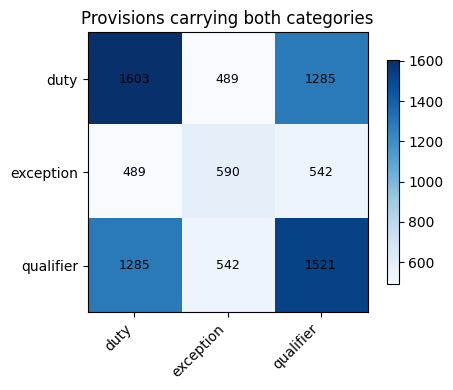

In [4]:
rates = flags.mean()
observed = (
    (flags.duty & flags.exception).mean()
    if {"duty", "exception"} <= set(flags.columns)
    else float("nan")
)
expected = rates.get("duty", 0) * rates.get("exception", 0)
print(f"duty rate: {rates.get('duty', 0):.3f}   exception rate: {rates.get('exception', 0):.3f}")
print(
    f"both, observed: {observed:.3f}   if independent: {expected:.3f}   lift: {observed / expected:.2f}x"
)

fig, ax = plt.subplots(figsize=(5, 4))
matrix = flags.T @ flags
im = ax.imshow(matrix, cmap="Blues")
ax.set(
    xticks=range(len(matrix)),
    yticks=range(len(matrix)),
    title="Provisions carrying both categories",
)
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(matrix.index)
for i in range(len(matrix)):
    for j in range(len(matrix)):
        ax.text(j, i, int(matrix.iloc[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Length is the confounder

More text, more chances to match. Any claim of the form "these provisions are
more normative" has to survive this control first.

In [5]:
counts = hits.groupby("provision_id").size().rename("hits")
joined = provisions.set_index("provision_id").join(counts).fillna({"hits": 0})
print(
    f"Spearman correlation, hits vs characters: {joined.hits.corr(joined.char_count, method='spearman'):.2f}"
)

buckets = pd.cut(
    joined.char_count,
    [0, 150, 300, 600, 1200, 100000],
    labels=["<150", "150-300", "300-600", "600-1200", ">1200"],
)
display(
    joined.groupby(buckets, observed=True)
    .agg(
        provisions=("hits", "size"),
        mean_hits=("hits", "mean"),
        share_with_any=("hits", lambda s: (s > 0).mean()),
    )
    .round(2)
)

Spearman correlation, hits vs characters: 0.73


,provisions,mean_hits,share_with_any
char_count,,,
<150,286,1.53,0.85
150-300,626,2.65,0.94
300-600,706,5.21,0.99
600-1200,286,8.60,0.99
>1200,48,15.65,1.00


## 5. Known failure modes, shown rather than described

These are the cases the review flagged. They are left in the marker set
deliberately — the point of an EDA page is to make them visible, not to hide
them behind a summary number.

**5a. "utan undantag" — a denial of an exception scores as an exception.**
The phrase says there is *no* exception; the marker sees the word `undantag`.

It does not occur in this statutory corpus at all, which is itself worth
recording: the failure mode was found on the constructed philosophical
passages, where the wording was deliberately chosen to expose it.

In [6]:
denials = provisions[provisions.text.str.contains("utan undantag", case=False, na=False)]
print(f"statutory provisions containing 'utan undantag': {len(denials)}")

from simulacria.measurement.corpus import load_corpus
from simulacria.selection.highlight import marker_spans

constructed = [
    row
    for row in load_corpus(ROOT / "corpus/philosophy_v1.yaml", ROOT)
    if "utan undantag" in row["text"].lower()
]
print(f"constructed passages containing 'utan undantag': {len(constructed)}")
for row in constructed[:2]:
    spans = [s for s in marker_spans(row["text"]) if s["category"] == "exception"]
    print(f"\n{row['passage_id']}: exception hits = {len(spans)} {[s['marker'] for s in spans]}")
    index = row["text"].lower().find("utan undantag")
    print("   ...", row["text"][max(0, index - 100) : index + 60].replace("\n", " "), "...")

statutory provisions containing 'utan undantag': 0
constructed passages containing 'utan undantag': 10

categorical-01: exception hits = 1 ['undantag']
   ... randet av den handling som löftet uttrycker och inte enbart en försäkran om god vilja. Detta gäller utan undantag, oberoende av egen fördel och av andras önskem ...

categorical-02: exception hits = 1 ['undantag']
   ... llan uppgiften och det uppgiftslämnaren känner till, med samma krav på tal och skrift. Detta gäller utan undantag, oberoende av egen fördel och av andras önskem ...


**5b. Bare `om` is ambiguous.** In Swedish it is both "if" (a condition) and
"about" (a topic). A qualifier marker built on it cannot tell them apart.

In [7]:
topical = provisions[
    provisions.text.str.contains(r"\bbestämmelser om\b", case=False, na=False, regex=True)
]
print(f"provisions containing 'bestämmelser om' ('provisions about ...'): {len(topical)}")

# Which sense a given `om` carries cannot be decided by another regex -- that is
# precisely the limitation being shown. So: print the context of every `om` hit
# in one provision and read them.
from simulacria.selection.highlight import marker_spans

example = provisions[provisions.provision_id == "sfs-1982-673:P1"].iloc[0]
print(f"\n{example.provision_id}: {example.document_title}\n")
print(example.text[:320].replace("\n", " "), "...\n")
for span in marker_spans(example.text):
    if span["marker"] != "om":
        continue
    start, end = int(span["start"]), int(span["end"])
    left = example.text[max(0, start - 45) : start].replace("\n", " ")
    right = example.text[end : end + 45].replace("\n", " ")
    print(f"  [{span['category']}] ...{left}<<om>>{right}...")

print(
    "\nHere `om` sits inside 'bestämmelser om' and 'Bestämmelser om' -- 'provisions\n"
    "about', a topic, not a condition. The same marker fires on 'Om anställningen\n"
    "upphör' ('if the employment ends'), which is a real condition. One regex, two\n"
    "senses, and no way to separate them lexically: this is why a qualifier is\n"
    "hand-annotated in the corpus rather than inferred from a marker."
)

provisions containing 'bestämmelser om' ('provisions about ...'): 69

sfs-1982-673:P1: Arbetstidslag (1982:673)

Denna lag gäller, med de inskränkningar som anges i 2 §, varje verksamhet där arbetstagare utför arbete för en arbetsgivares räkning.  Allmänna skyddsbestämmelser av betydelse för förläggningen av arbetstid finns i 2 kap. 1 § arbetsmiljölagen (1977:1160). Särskilda bestämmelser om arbetstiden för minderåriga finns i 5  ...

  [qualifier] ...ljölagen (1977:1160). Särskilda bestämmelser <<om>> arbetstiden för minderåriga finns i 5 kap. d...

Here `om` sits inside 'bestämmelser om' and 'Bestämmelser om' -- 'provisions
about', a topic, not a condition. The same marker fires on 'Om anställningen
upphör' ('if the employment ends'), which is a real condition. One regex, two
senses, and no way to separate them lexically: this is why a qualifier is
hand-annotated in the corpus rather than inferred from a marker.


**5c. Double counting.** One clause can match several markers of the same
category, so hit counts are not counts of distinct semantic elements.

In [8]:
doubles = (
    hits.groupby(["provision_id", "category"])
    .agg(hits=("marker", "size"), distinct_markers=("marker", "nunique"))
    .query("hits > distinct_markers or distinct_markers > 1")
    .sort_values("hits", ascending=False)
)
print(f"{len(doubles):,} provision/category pairs carry more than one marker hit")
display(doubles.head(8))
worst = doubles.head(1)
if len(worst):
    provision_id = worst.index[0][0]
    display(
        hits[hits.provision_id == provision_id][
            ["category", "marker", "matched_span", "char_offset"]
        ]
    )
    print(provisions.set_index("provision_id").loc[provision_id, "text"][:400])

2,172 provision/category pairs carry more than one marker hit


,,hits,distinct_markers
provision_id,category,,
sfs-2026-1283:overgang:2026-1283,qualifier,25,4
sfs-1982-80:P6c,qualifier,24,4
sfs-2026-1283:overgang:2026-1283,duty,20,2
sfs-2026-333:P1,qualifier,16,1
sfs-1976-580:P38,qualifier,16,4
sfs-1982-673:P27,qualifier,15,4
sfs-2026-1281:K1P5,qualifier,15,2
sfs-2026-843:P12,qualifier,15,2


,category,marker,matched_span,char_offset
4985,duty,ska,ska,182
4986,duty,ska,ska,335
4987,duty,ska,ska,435
4988,duty,ska,ska,878
4989,duty,ska,ska,1027
4990,duty,ska,ska,1197
4991,duty,ska,ska,1615
4992,duty,ska,ska,1705
4993,duty,ska,ska,1947
4994,duty,ska,ska,2210


2026:1283

1. Denna lag träder i kraft den 1 januari 2027.

2. Bestämmelserna i 5 b § i den upphävda lagen (1902:71 s. 1) innefattande vissa bestämmelser för elektriska anläggningar ska fortfarande gälla för ledningar som före den 1 januari
1998 har dragits fram efter expropriation. Det som i den paragrafen sägs om fastighetsdomstol ska i stället gälla mark- och miljödomstol.

3. Om en ledning har


## 6. What this means for the experiment

- Marker counts are an upper bound on normative elements, never a count of them.
- Anything compared across provisions has to control for length first.
- The three annotated probe passages were hand-checked; the markers only chose
  where to look. That separation is the reason selection may not be imported by
  measurement, and it is why these failure modes are tolerable here and would
  not be tolerable inside the instrument.